## 12. 다중 분류 - 원-핫 인코딩 (One-hot Encoding)
* 여러 개 값의 문자열로 이루어진 데이터를 0과 1로만 이루어진 형태로 만들어주는 과정
  
* 변환 방법  

    (1) 판다스의 get_dummies() 함수 활용  
    (2) Sklearn의 LabelEncoder와 Tensorflow의 tf.keras.utils.to_categorical()을 활용하는 방법

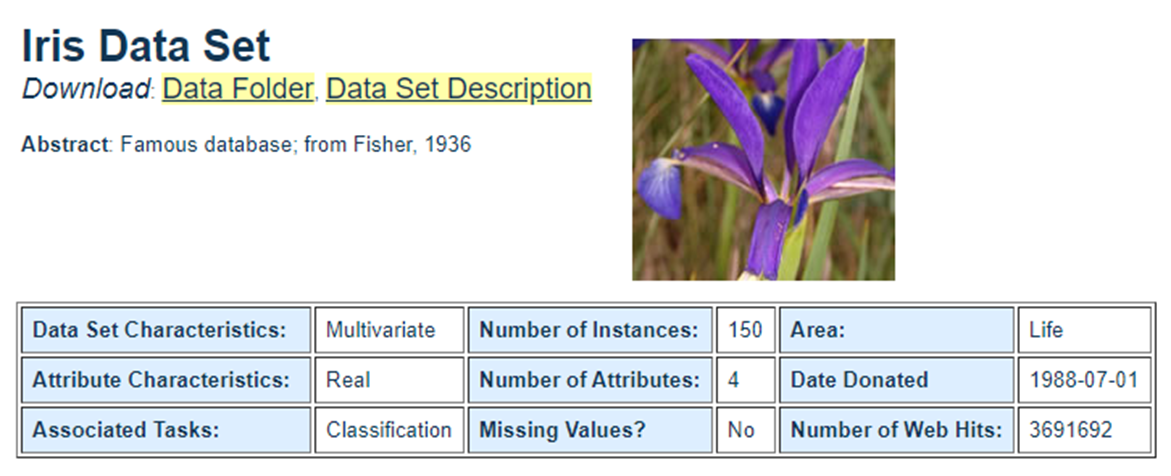
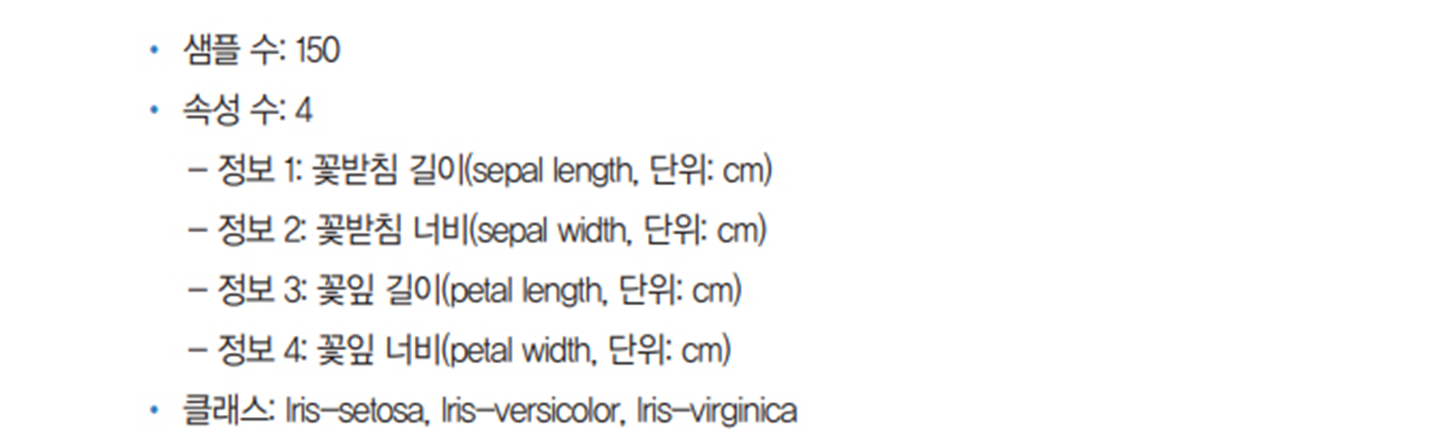

In [1]:
import tensorflow as tf
import pandas as pd

In [2]:
df_iris = pd.read_csv('./data/iris3.csv')
df_iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### **상관도 그래프** - 탐색적 데이터분석 (EDA)

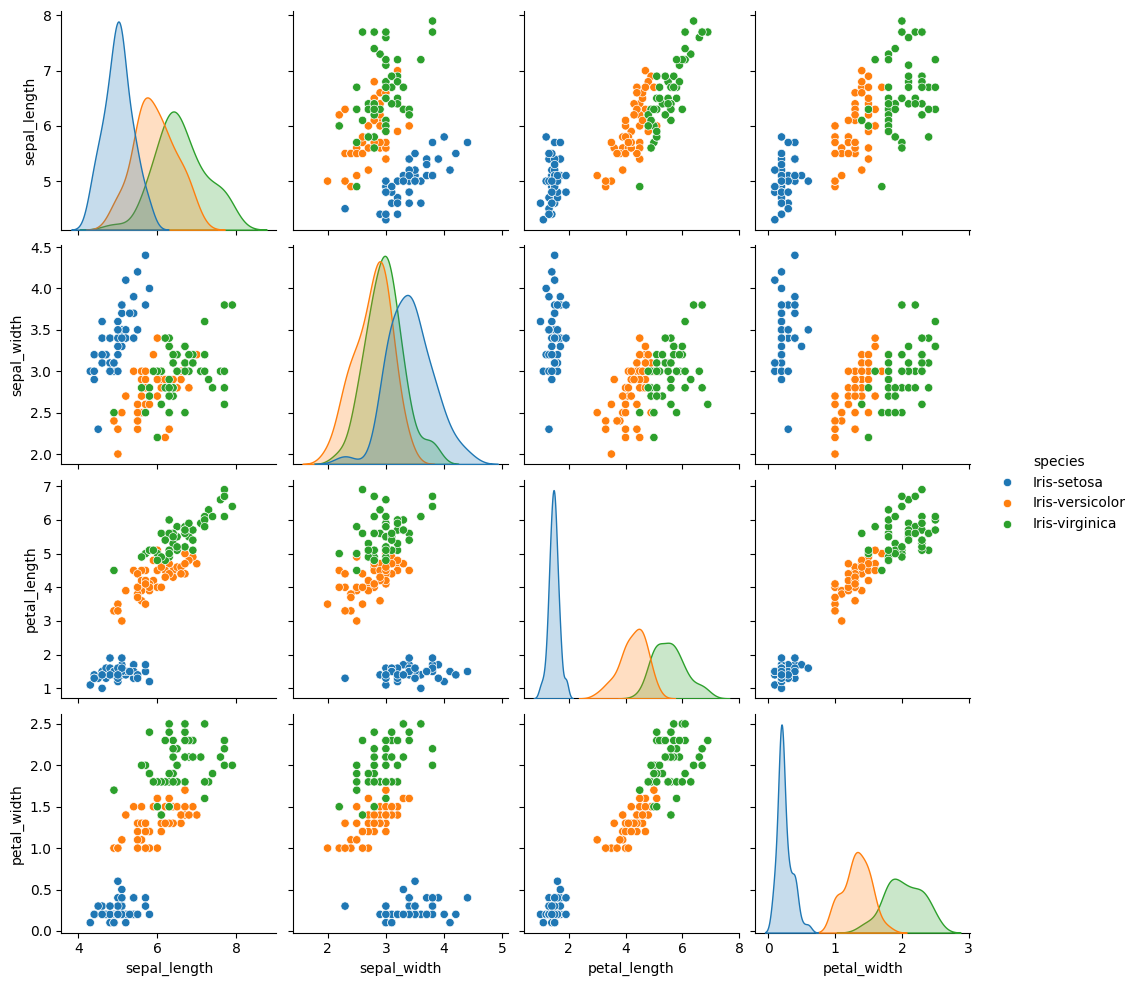

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프로 확인해 봅시다.
sns.pairplot(df_iris, hue='species')
plt.show()

In [4]:
df_iris.iloc[:, :4].values.dtype

dtype('float64')

In [5]:
## X, Y 데이터셋 생성
X = df_iris.iloc[:, :-1]   # Pandas DataFrame
Y = df_iris.iloc[:, -1]    # Pandas Series data
X.shape, Y.shape

((150, 4), (150,))

In [6]:
Y.value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
X.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object

### **One-hot Encoding**

### (1) Pandas의 get_dummies() 로 원핫인코딩

**원핫 인코딩 (One-Hot Encoding)**
* 여러 개의 값으로 된 문자열을 0과 1로만 이루어진 형태로 만들어 주는 과정을 원-핫 인코딩(one-hot encoding)이라고 함
* 원-핫 인코딩은 판다스가 제공하는 get_dummies() 함수를 사용하면 간단하게 해낼 수 있음

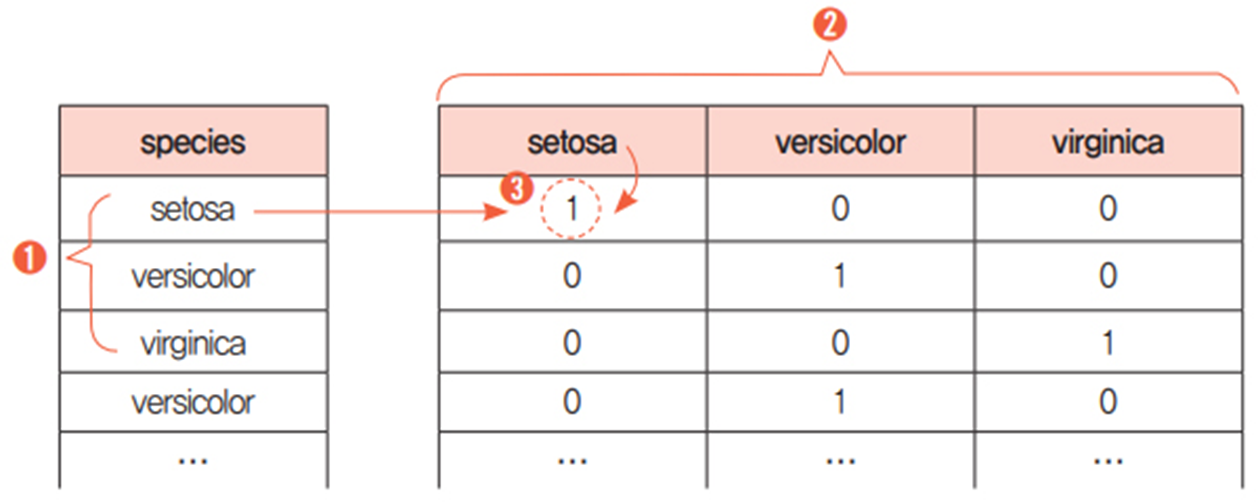

In [8]:
Y.values

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [9]:
pd.get_dummies(Y)   # 해당 위치에 1, 나머지 위치에 0을 넣어줌

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [10]:
## (1) Pandas get_dummies 함수로 원핫인코딩
df_Y_onehot = pd.get_dummies(Y).astype(int)
# Y_onehot = pd.get_dummies(Y.values)  # numpy데이터를 입력해도 같은 결과!
df_Y_onehot

,Iris-setosa,Iris-versicolor,Iris-virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
145,0,0,1
146,0,0,1
147,0,0,1
148,0,0,1


In [11]:
# One Hot Encoding 했을 때 각 자리가 무슨 클래스인지 확인하기 위해 컬럼 확인
y_columns = df_Y_onehot.columns
y_columns

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')

In [12]:
Y_onehot = df_Y_onehot.values.astype(int)
Y_onehot[98:103], Y_onehot.shape

(array([[0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1]]),
 (150, 3))

### (2) Sklearn과 Tensorflow로 One-hot Encoding

* Sklearn의 LabelEncoder는 데이터를 정수로 바꾸어줌

In [13]:
Y.head(3)

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
Name: species, dtype: object

In [14]:
from sklearn.preprocessing import LabelEncoder

e = LabelEncoder()
e.fit(Y)  # 학습
e.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [15]:
# 정수 인코딩 (setosa=0, versicolor=1, virginica=2)
Y_encoded = e.transform(Y)
Y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

* Tensorflow의 to_categorical 함수는 정수를 onehot 형태로 바꾸어줌

In [16]:
## 정수인코딩 -> 원핫인코딩
from tensorflow.keras.utils import to_categorical

Y_onehot = to_categorical(Y_encoded)
Y_onehot

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

### **다중 분류 - Softmax**

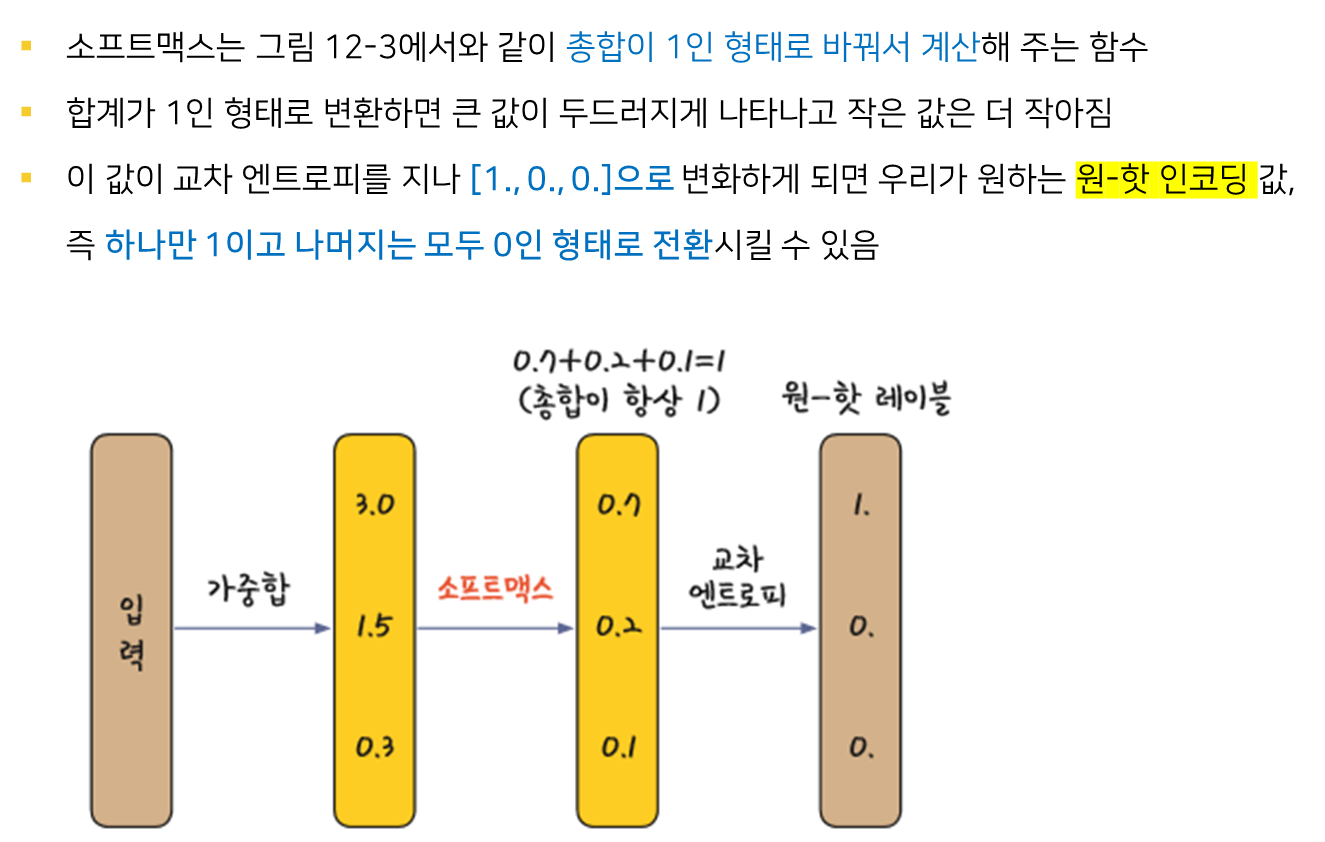

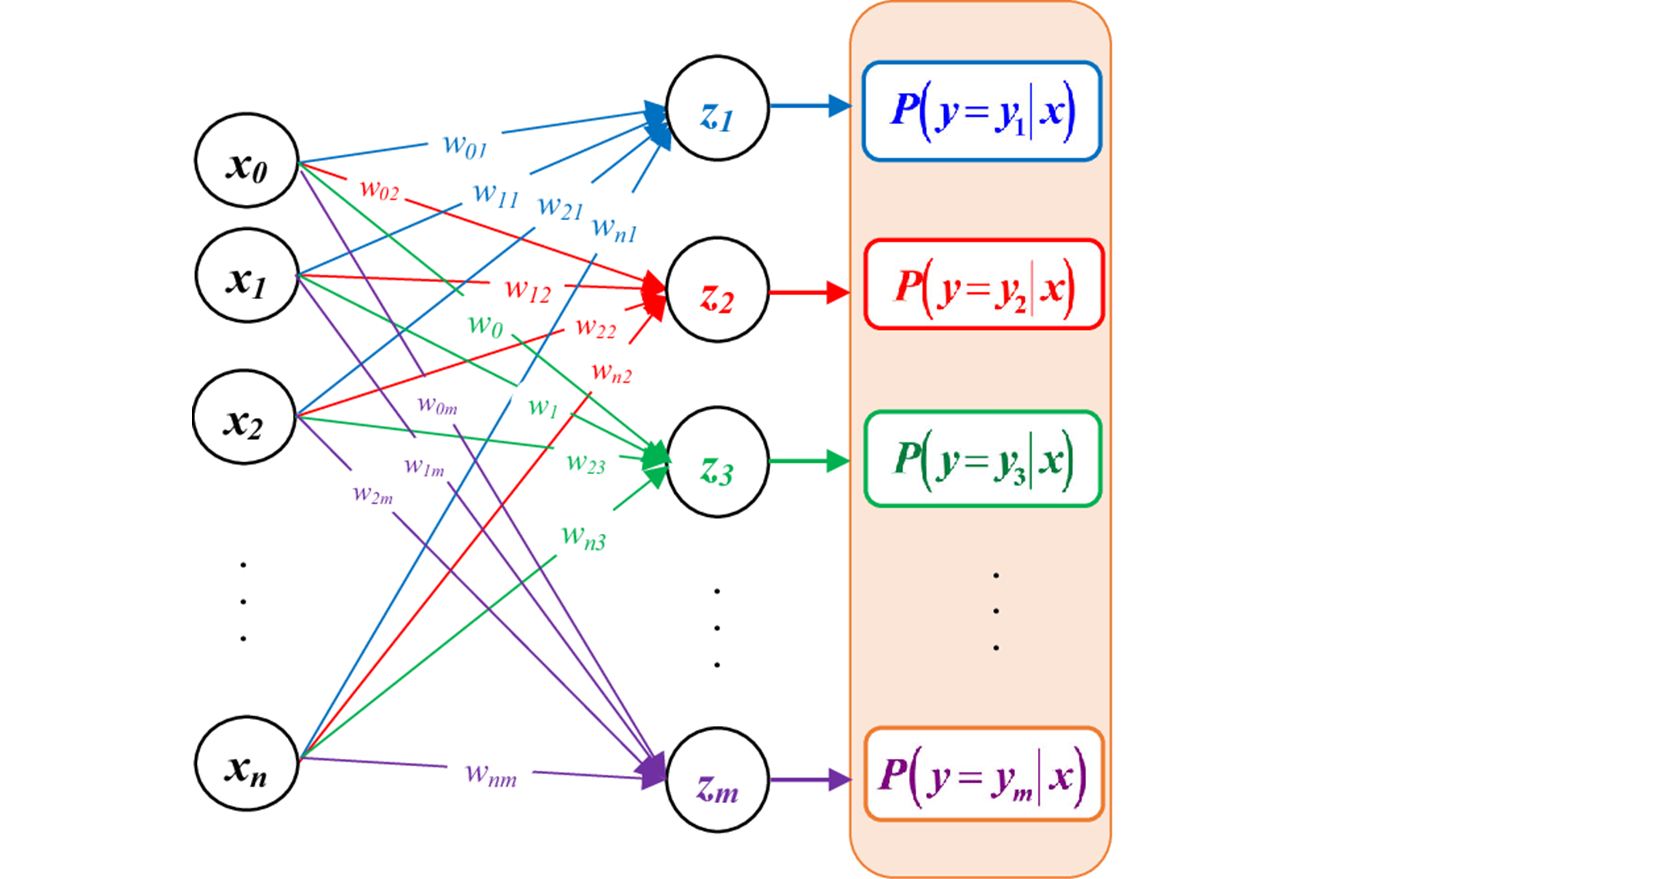

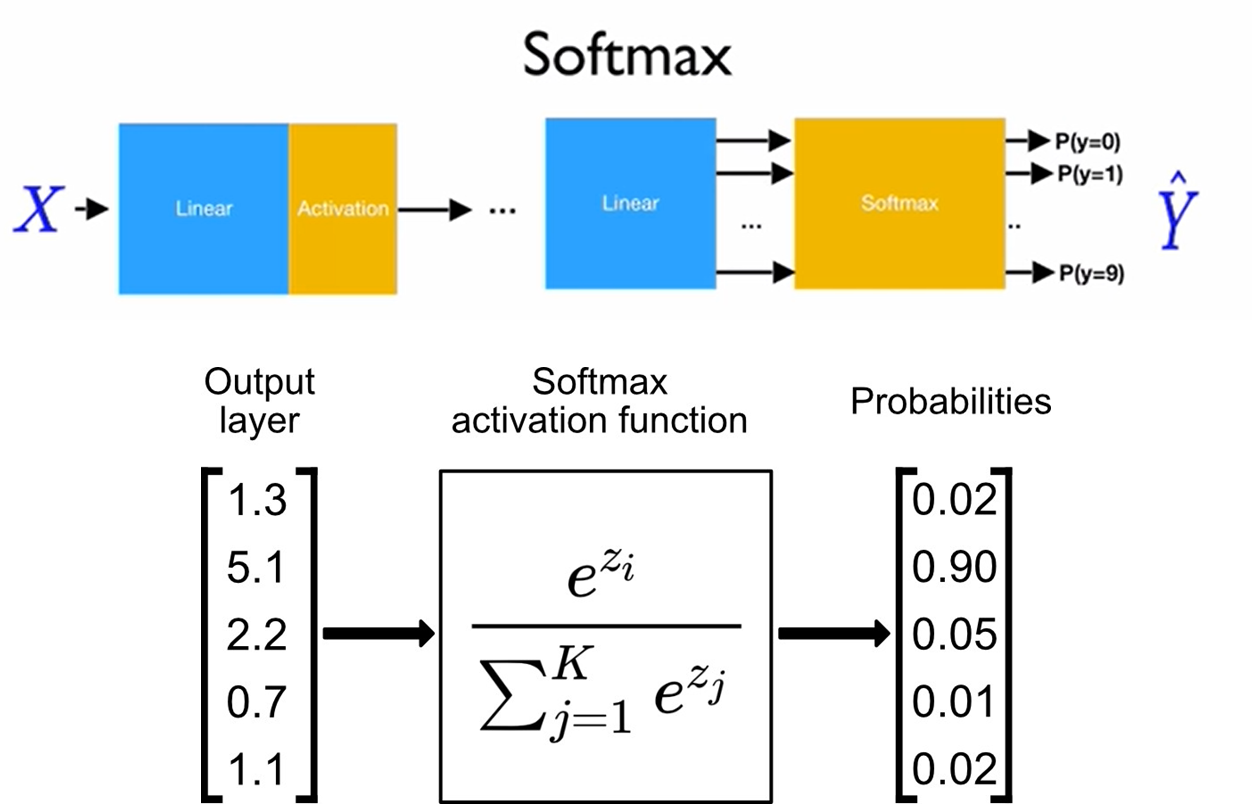

In [17]:
## Softmax 함수 구현
import numpy as np
def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z))

Z = np.array([1.3, 5.1, 2.2, 0.7, 1.1])
s = softmax(Z)
s.round(2)

array([0.02, 0.9 , 0.05, 0.01, 0.02])

In [18]:
Z, np.exp(Z), np.exp(Z).sum()

(array([1.3, 5.1, 2.2, 0.7, 1.1]),
 array([  3.66929667, 164.0219073 ,   9.0250135 ,   2.01375271,
          3.00416602]),
 181.73413619837197)

In [19]:
P = np.exp(Z) / np.exp(Z).sum()
P

array([0.02019046, 0.90253769, 0.04966053, 0.01108076, 0.01653055])

In [20]:
s.sum()

1.0

In [21]:
## softmax결과의 가장 값이 큰 곳의 인덱스 : 예측된 클래스
s.argmax()

1

In [22]:
s[s.argmax()]  # 가장 큰 값 (확률)

0.9025376890165726

#### **다중분류 정리**
#### **(1) 활성화 함수 (activation function) : `activation='softmax'`** 
* 소프트맥스 함수는각 항목당 예측 확률을 0과 1 사이의 값으로 나타내 주는데, 이때 각 샘플당 예측 확률의 총합이 1인 형태로 바꾸어 주게 됨(예를 들어 1번 샘플의 경우 0.2 + 0.7 + 0.1 = 1이 됨)
* `activation`란에 `‘softmax’`라고 적어 주는 것으로 소프트맥스 함수를 바로 적용 할수 있음

#### **(2) 손실 함수 (loss function) : `loss='categorical_crossentropy'`** 
* 마찬가지로 **손실 함수**도 이전과는 달라져야 함
* 이항 분류에서 binary_crossentropy를 썼다면, 다항 분류에서는 `categorical_crossentropy`를 쓰면 됨

```python
    # 모델의 설정
    model = Sequential()
    model.add(Dense(16, input_dim=4, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    # 모델 컴파일 
    model.compile(loss='categorical_crossentropy', 
                optimizer='adam',
                metrics=['accuracy'])

```


In [23]:
#########################################################
# 12. 다중분류 - One Hot Encoding
# - 아이리스 품종 예측
# - One-hot encoding, - label encoder 사용
# - 활성화함수(Activation Function) : softmax
# - 비용함수(loss) : 'categorical_crossentropy'
#########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 입력
df = pd.read_csv('./data/iris3.csv')

# 데이터 분류
dataset = df.values
X = dataset[:, 0:4].astype(float)  # dtype 'o'를 float로 바꾸어줘야 함
Y = dataset[:, 4]
X.shape, Y.shape

((150, 4), (150,))

In [24]:
# 문자열을 숫자로 변환 -> One Hot Encoding
e = LabelEncoder()
e.fit(Y)  # 라벨인코더를 Y_obj 데이터에 적용
print("*** e.classes_ : ", e.classes_)   # 라벨인코딩 결과 각 클래스명의 array
Y_encoded = e.transform(Y) # 문자데이터(species)를 0, 1, 2로 변환
Y_onehot = tf.keras.utils.to_categorical(Y_encoded) # One Hot Encoding
# Y_onehot  # [1, 0, 0], [0, 1, 0], [0, 0, 1] 형태
Y_onehot.shape  # (150, 3)

*** e.classes_ :  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


(150, 3)

In [25]:
# 모델 설정
model = Sequential()
model.add(Dense(12,  input_dim=4, activation='relu'))
model.add(Dense(8,  activation='relu'))
model.add(Dense(3, activation='softmax')) # 3개 클래스 분류!
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                60        
                                                                 
 dense_1 (Dense)             (None, 8)                 104       
                                                                 
 dense_2 (Dense)             (None, 3)                 27        
                                                                 
Total params: 191
Trainable params: 191
Non-trainable params: 0
_________________________________________________________________


In [26]:

# 모델 컴파일 
model.compile(loss='categorical_crossentropy',  # 다중 분류 문제에서는 categorical_crossentropy 사용
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_onehot, epochs=100, batch_size=5) # 반드시 Y_onehot을 입력해야 함(원핫인코딩된 데이터)


Epoch 1/100
30/30 [==============================] - 1s 1ms/step - loss: 1.4612 - accuracy: 0.3333
Epoch 2/100
30/30 [==============================] - 0s 1ms/step - loss: 0.9858 - accuracy: 0.4933
Epoch 3/100
30/30 [==============================] - 0s 1ms/step - loss: 0.9139 - accuracy: 0.5467
Epoch 4/100
30/30 [==============================] - 0s 1ms/step - loss: 0.8714 - accuracy: 0.6400
Epoch 5/100
30/30 [==============================] - 0s 1ms/step - loss: 0.8324 - accuracy: 0.7400
Epoch 6/100
30/30 [==============================] - 0s 2ms/step - loss: 0.7900 - accuracy: 0.7267
Epoch 7/100
30/30 [==============================] - 0s 2ms/step - loss: 0.7593 - accuracy: 0.8200
Epoch 8/100
30/30 [==============================] - 0s 2ms/step - loss: 0.7187 - accuracy: 0.6733
Epoch 9/100
30/30 [==============================] - 0s 2ms/step - loss: 0.6740 - accuracy: 0.8267
Epoch 10/100
30/30 [==============================] - 0s 2ms/step - loss: 0.6359 - accuracy: 0.7733
Epoch 11/

In [27]:
# 결과 출력 (모델 평가)
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_onehot)[1]))  #[0]:loss, [1]:accuracy

5/5 [==============================] - 0s 2ms/step - loss: 0.0722 - accuracy: 0.9733

 Accuracy: 0.9733


In [28]:
model.evaluate(X, Y_onehot, verbose=0)  # [loss, accuracy]

[0.0721578449010849, 0.9733333587646484]

### history 데이터로 Loss와 Accuracy 그래프 그리기

In [29]:
hist.history.keys()

dict_keys(['loss', 'accuracy'])

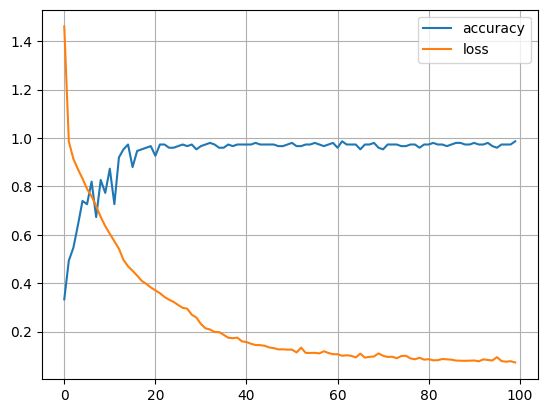

In [30]:
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['loss'], label='loss')
plt.legend()
# plt.yticks([0, 0.5, 1])
plt.grid()
plt.show()

### 검증 데이터로 정확도 알아보기 : model.evaluate(X, Y)

In [31]:
model.evaluate(X, Y_onehot)

5/5 [==============================] - 0s 2ms/step - loss: 0.0722 - accuracy: 0.9733


[0.0721578449010849, 0.9733333587646484]

In [32]:
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_onehot, verbose=0)[1]))  #[0]:loss, [1]:accuracy


 Accuracy: 0.9733


### 새로운 데이터로 꽃의 종류 예측해 보기

In [33]:
X.shape

(150, 4)

In [34]:
## 하나의 꽃 데이터로 종류 예측하기
new_X = X[57].reshape(-1, 4)
new_X  # 2차원 데이터 이어야 함

array([[4.9, 2.4, 3.3, 1. ]])

In [35]:
new_X.shape

(1, 4)

In [36]:
Y_hat = model.predict(new_X, verbose=0)  # 예측 확률값 출력
Y_hat.round(3)

array([[0.012, 0.984, 0.004]], dtype=float32)

In [37]:
e.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [38]:
e.classes_[1]

'Iris-versicolor'

In [39]:
Y_hat.argmax()

1

In [40]:
e.classes_[Y_hat.argmax()]

'Iris-versicolor'

In [41]:
new_X = np.array([ [5.1, 3.5, 1.4, 0.2],
                   [7.1, 3. , 5.9, 2.1],
                   [4.7, 3.2, 1.3, 0.2],
                   [4.9, 2.4, 3.3, 1. ]])   # softmax의 결과 array로 출력

model.predict(new_X).round(5)

1/1 [==============================] - 0s 45ms/step


array([[0.99891, 0.00109, 0.     ],
       [0.     , 0.00732, 0.99268],
       [0.99809, 0.00191, 0.     ],
       [0.01154, 0.98406, 0.0044 ]], dtype=float32)

In [42]:
Y_predicted = model.predict(new_X).argmax(axis=1)  
Y_predicted

1/1 [==============================] - 0s 32ms/step


array([0, 2, 0, 1], dtype=int64)

### LabelEncoder의 e.classes_ 로 0, 1, 2,로 변환된 데이터의 순서와 명칭을 가져올 수 있음

In [43]:
e.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [44]:
### 4개의 꽃 종류 예측 (꽃 이름으로 return)
e.classes_[Y_predicted]

array(['Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-versicolor'],
      dtype=object)

### [연습]학습된 모델로 계산된 결과를 꽃이름으로 가져오기

In [45]:
df.loc[[10, 15, 77, 123]] # 150개 데이터 중 4개 추출

,sepal_length,sepal_width,petal_length,petal_width,species
10,5.4,3.7,1.5,0.2,Iris-setosa
15,5.7,4.4,1.5,0.4,Iris-setosa
77,6.7,3.0,5.0,1.7,Iris-versicolor
123,6.3,2.7,4.9,1.8,Iris-virginica


In [46]:
new_X = df.loc[[10, 15, 77, 123]].iloc[:, :-1].values
new_X

array([[5.4, 3.7, 1.5, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.7, 3. , 5. , 1.7],
       [6.3, 2.7, 4.9, 1.8]])

In [47]:
## 예측
e.classes_[model.predict(new_X).argmax(axis=1)]

1/1 [==============================] - 0s 44ms/step


array(['Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
      dtype=object)

In [48]:
## 정답
Y[[10, 15, 77, 123]]

array(['Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
      dtype=object)

## Pandas 의 get_dummies로 One Hot Encoding을 한 경우

In [49]:
#########################################################
# 12. 다중분류 - One Hot Encoding
# - 아이리스 품종 예측
# - One-hot encoding : pd.get_dummies 사용
#########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 입력
df = pd.read_csv('./data/iris3.csv')

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values  # iris 꽃 이름 array

df_Y = pd.get_dummies(df.species)
Y_onehot = df_Y.values
print("*** One Hot 컬럼명 :", df_Y.columns)   # One Hot vector에서 꽃이름으로 변환할 때 사용
Y_onehot

*** One Hot 컬럼명 : Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')


array([[ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ T

In [50]:
# 모델의 설정
model = Sequential()
model.add(Dense(16, input_dim=4, activation='relu'))
model.add(Dense(3, activation='softmax'))

# 모델 컴파일 
model.compile(loss='categorical_crossentropy', 
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_onehot, epochs=50, batch_size=1)

# 결과 출력
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_onehot)[1]))  #[0]:loss, [1]:accuracy

Epoch 1/50
150/150 [==============================] - 1s 2ms/step - loss: 1.9911 - accuracy: 0.5200
Epoch 2/50
150/150 [==============================] - 0s 2ms/step - loss: 0.8130 - accuracy: 0.6933
Epoch 3/50
150/150 [==============================] - 0s 2ms/step - loss: 0.6503 - accuracy: 0.7667
Epoch 4/50
150/150 [==============================] - 0s 2ms/step - loss: 0.5527 - accuracy: 0.8933
Epoch 5/50
150/150 [==============================] - 0s 2ms/step - loss: 0.4827 - accuracy: 0.8400
Epoch 6/50
150/150 [==============================] - 0s 2ms/step - loss: 0.4473 - accuracy: 0.8733
Epoch 7/50
150/150 [==============================] - 0s 2ms/step - loss: 0.3992 - accuracy: 0.9600
Epoch 8/50
150/150 [==============================] - 0s 2ms/step - loss: 0.3686 - accuracy: 0.9000
Epoch 9/50
150/150 [==============================] - 0s 2ms/step - loss: 0.3585 - accuracy: 0.9600
Epoch 10/50
150/150 [==============================] - 0s 2ms/step - loss: 0.3331 - accuracy: 0.9333

### 새로운 데이터로 꽃의 종류 예측하기 (pd.get_dummies 사용시)

In [51]:
new_X = np.array([ [5.1, 3.5, 1.4, 0.2],
                   [7.1, 3. , 5.9, 2.1],
                   [4.7, 3.2, 1.3, 0.2],
                   [4.9, 2.4, 3.3, 1. ]])   # softmax의 결과 array로 출력

Y_predicted = model.predict(new_X).argmax(axis=1)
Y_predicted

1/1 [==============================] - 0s 125ms/step


array([0, 2, 0, 1], dtype=int64)

<Axes: >

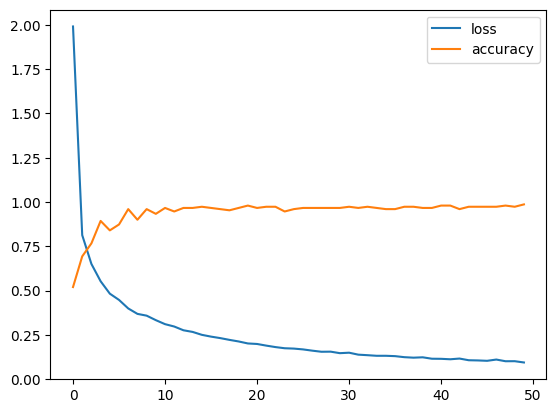

In [52]:
import pandas as pd
pd.DataFrame(hist.history).plot()

In [53]:
df_Y = pd.get_dummies(Y)
df_Y.columns

Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')

In [54]:
Y_predicted_names = df_Y.columns[Y_predicted]
Y_predicted_names

Index(['Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-versicolor'], dtype='object')

In [55]:
#########################################################
# 12. 다중분류 - One Hot Encoding
# - 아이리스 품종 예측
# - One-hot encoding : pd.get_dummies 사용
# - One Hot Encoding 없이 sparse-categorical-crossentropy 사용
#########################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 데이터 입력
df = pd.read_csv('./data/iris3.csv')

X = df.iloc[:, :-1].values
Y = df.iloc[:, -1].values  # iris 꽃 이름 array

### One Hot Encoding 없이 sparse_categorical_crossentropy 사용
# df_Y = pd.get_dummies(df.species)
# Y_onehot = df_Y.values
# print("*** One Hot 컬럼명 :", df_Y.columns)   # One Hot vector에서 꽃이름으로 변환할 때 사용
e = LabelEncoder()
e.fit(Y) # 학습
print(e.classes_)

Y_encoded = e.transform(Y)

# 모델의 설정
model = Sequential()
model.add(Dense(16, input_dim=4, activation='relu'))
model.add(Dense(3, activation='softmax'))

# 모델 컴파일  (One Hot Encoding 없이 - loss='sparse_categorical_crossentropy' 사용)
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam',
              metrics=['accuracy'])

# 모델 실행
hist = model.fit(X, Y_encoded, epochs=50)

# 결과 출력 
print("\n Accuracy: %.4f" % (model.evaluate(X, Y_encoded)[1]))  #[0]:loss, [1]:accuracy

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Epoch 1/50
5/5 [==============================] - 1s 4ms/step - loss: 3.9938 - accuracy: 0.3333
Epoch 2/50
5/5 [==============================] - 0s 3ms/step - loss: 3.7364 - accuracy: 0.3333
Epoch 3/50
5/5 [==============================] - 0s 3ms/step - loss: 3.4855 - accuracy: 0.3333
Epoch 4/50
5/5 [==============================] - 0s 2ms/step - loss: 3.2456 - accuracy: 0.3333
Epoch 5/50
5/5 [==============================] - 0s 3ms/step - loss: 2.9977 - accuracy: 0.3333
Epoch 6/50
5/5 [==============================] - 0s 3ms/step - loss: 2.7768 - accuracy: 0.3333
Epoch 7/50
5/5 [==============================] - 0s 3ms/step - loss: 2.5417 - accuracy: 0.3333
Epoch 8/50
5/5 [==============================] - 0s 3ms/step - loss: 2.3338 - accuracy: 0.3333
Epoch 9/50
5/5 [==============================] - 0s 4ms/step - loss: 2.1234 - accuracy: 0.3333
Epoch 10/50
5/5 [==============================] - 0s 3ms/step - loss: 1.9243 - accur

In [56]:
## 새로운 데이터로 꽃 이름 예측하기
new_X = X[[10, 15, 77, 123]]
model.predict(new_X) # One Hot Encoding 없이 예측하였으나, One Hot으로 예측한 결과와 같은 형태로 나옴

1/1 [==============================] - 0s 78ms/step


array([[0.81456673, 0.16317642, 0.02225676],
       [0.8940657 , 0.09430014, 0.01163417],
       [0.0635593 , 0.44571027, 0.49073038],
       [0.04923148, 0.3835306 , 0.5672379 ]], dtype=float32)

In [57]:
## 정수 인코딩할때 저장된 클래스 이름
e.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [58]:
model.predict(new_X).argmax(axis=1)

1/1 [==============================] - 0s 38ms/step


array([0, 0, 2, 2], dtype=int64)

In [59]:
e.classes_[model.predict(new_X).argmax(axis=1)]

1/1 [==============================] - 0s 47ms/step


array(['Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica'],
      dtype=object)

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
from sklearn.preprocessing import LabelEncoder  # 추가된 라이브러리

# 1. 데이터 입력
df = pd.read_csv('./data/iris3.csv')

X = df.iloc[:, :-1].values
Y_obj = df.iloc[:, -1].values  # 원본 문자열 데이터

# 2. Label Encoding (문자열 -> 정수)
# 예: 'Iris-setosa' -> 0, 'Iris-versicolor' -> 1, 'Iris-virginica' -> 2
encoder = LabelEncoder()
encoder.fit(Y_obj)
Y = encoder.transform(Y_obj)
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [62]:
# 3. 모델의 설정
model = Sequential()
model.add(Dense(16, input_dim=4, activation='relu'))
model.add(Dense(3, activation='softmax')) # 출력층 노드는 클래스 개수인 3개

# 4. 모델 컴파일
# 정수 인코딩 데이터를 사용하므로 sparse_categorical_crossentropy 설정
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer='adam',
              metrics=['accuracy'])

# 5. 모델 실행
hist = model.fit(X, Y, epochs=100, verbose=1)

# 6. 결과 출력 
print("\n Accuracy: %.4f" % (model.evaluate(X, Y)[1]))

Epoch 1/100
5/5 [==============================] - 0s 2ms/step - loss: 3.2267 - accuracy: 0.3333
Epoch 2/100
5/5 [==============================] - 0s 2ms/step - loss: 2.9646 - accuracy: 0.3333
Epoch 3/100
5/5 [==============================] - 0s 3ms/step - loss: 2.7020 - accuracy: 0.3333
Epoch 4/100
5/5 [==============================] - 0s 3ms/step - loss: 2.4604 - accuracy: 0.3333
Epoch 5/100
5/5 [==============================] - 0s 3ms/step - loss: 2.2212 - accuracy: 0.3333
Epoch 6/100
5/5 [==============================] - 0s 4ms/step - loss: 2.0002 - accuracy: 0.3333
Epoch 7/100
5/5 [==============================] - 0s 4ms/step - loss: 1.7969 - accuracy: 0.3333
Epoch 8/100
5/5 [==============================] - 0s 3ms/step - loss: 1.6256 - accuracy: 0.3333
Epoch 9/100
5/5 [==============================] - 0s 3ms/step - loss: 1.4748 - accuracy: 0.3333
Epoch 10/100
5/5 [==============================] - 0s 3ms/step - loss: 1.3655 - accuracy: 0.3267
Epoch 11/100
5/5 [===========

In [63]:
model.predict(X[0:5])  # 각 클래스에 대한 예측 확률

1/1 [==============================] - 0s 86ms/step


array([[0.79766965, 0.12353592, 0.07879446],
       [0.7574868 , 0.15492728, 0.08758588],
       [0.76959187, 0.14098349, 0.08942474],
       [0.7262766 , 0.16266966, 0.11105371],
       [0.7936013 , 0.12232033, 0.08407847]], dtype=float32)

In [64]:
import tensorflow as tf
tf.__version__

'2.10.0'